# Import packages

In [2]:
import pandas as pd
import re
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

from utils.plotting import plot_histogram_distributions, plot_feature_space
from utils.mahalanobis import extract_features_from_df, Mahalanobis

# Load data

In [3]:
train_df = pd.read_parquet('data/processed/train.parquet')
test_df = pd.read_parquet('data/processed/test.parquet')

Since are just baseline models, the hyperparam df will not be used separately. Instead, it will be concatenated with the threshold df and used for threshold decision

In [4]:
hyperparam_df = pd.read_parquet('data/processed/hyperparam.parquet')
threshold_df = pd.read_parquet('data/processed/threshold.parquet')

val_df = pd.concat([hyperparam_df, threshold_df], axis=0).reset_index(drop=True)

In [5]:
# Columns with time series data (t1, t2, ..., t140)
ts_columns = [col for col in train_df.columns if re.match(r't\d+$', col)]

# Baseline Model

Before implementing the Conv1D Autoencoder, one classical anomaly detection method will be tested as a baseline:

The **Mahalanobis distance** uses summary statistics extracted from the time series, measuring how far each series deviates from the normal distribution in feature space. Provides a purely statistical baseline for comparison.

## Mahalanobis distance with threshold

The Mahalanobis distance measures how far a data point is from the center of a distribution, taking into account the variance and correlation between features. Unlike Euclidean distance, it accounts for the shape of the data by using the covariance matrix, effectively normalizing across all dimensions simultaneously. In this notebook, from each time series, `n` summary statistical features are extracted. Therefore, each time series became a point in a `n` dimensional space. Points with a large Mahalanobis distance from the normal distribution are likely to represent anomalies.

Below 9 features (mean, std, min, max, amplitude, quartiles, ...) are extracted from each time series. 

In [6]:
train_features = extract_features_from_df(train_df[ts_columns])
val_features = extract_features_from_df(val_df[ts_columns])
test_features = extract_features_from_df(test_df[ts_columns])

Then the model is trained in normal data:

In [7]:
malahanobis_model = Mahalanobis()
malahanobis_model.fit(train_features)

Below the distributions of the mahalanobis distances are plotted in a histogram. Using this histogram, a threshold is defined in order to separate the normal and anomalous distributions.

Visually, a good choice for the threshold would be 3.5.

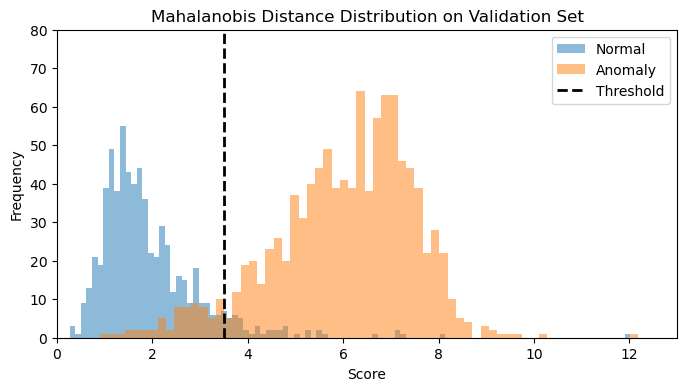

In [8]:
val_scores = malahanobis_model.score(val_features)

labels = val_df['detailedTarget'].map(lambda x: 'Normal' if x == 'Normal' else 'Anomaly')
normal_mask = labels == 'Normal'
anomaly_mask = labels == 'Anomaly'

plot_histogram_distributions(
    title='Mahalanobis Distance Distribution on Validation Set',
    xlabel='Score',
    points=[val_scores[normal_mask], val_scores[anomaly_mask]],
    labels=['Normal', 'Anomaly'],
    figsize=(8, 4),
    xlim=[0, 13],
    ylim=[0, 80],
    threshold=3.5
)

Using the threshold defined above, it is possible to classify the test data and compute the score metrics for this method.

In [9]:
th = 3.5

test_scores = malahanobis_model.score(test_features)
test_labels = test_df['detailedTarget'].map(lambda x: 0 if x == 'Normal' else 1)

predicted_labels = (test_scores > th).astype(int)

## Results

As shown below, the model produced 47 False Negatives and 23 False Positives. The 47 False Negatives represent a considerable concern, as these are anomalies that went undetected.

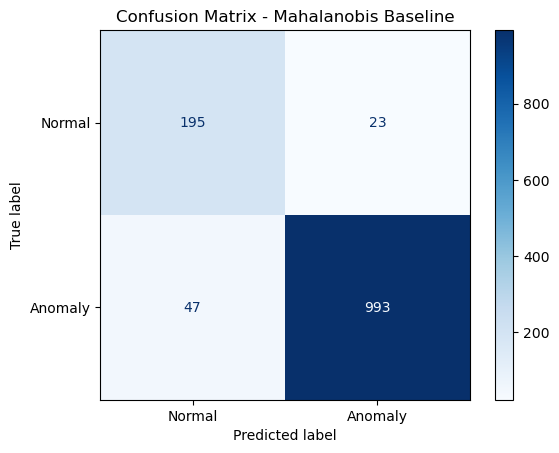

In [10]:
ConfusionMatrixDisplay.from_predictions(
    test_labels, predicted_labels,
    display_labels=['Normal', 'Anomaly'],
    cmap='Blues'
)
plt.title('Confusion Matrix - Mahalanobis Baseline')
plt.show()

Analyzing more metrics such as Precision, Recall and the F1-Score:

In [11]:
print(classification_report(test_labels, predicted_labels, target_names=['Normal', 'Anomaly']))

              precision    recall  f1-score   support

      Normal       0.81      0.89      0.85       218
     Anomaly       0.98      0.95      0.97      1040

    accuracy                           0.94      1258
   macro avg       0.89      0.92      0.91      1258
weighted avg       0.95      0.94      0.95      1258



Note that the F1-score for the Anomaly class is extremely high (0.97) while for the Normal class it is 0.85. This happens because the test set is mostly composed of anomaly examples, since most of the normal examples were reserved for training and validation.

In [19]:
labels = test_df['detailedTarget'].map(lambda x: 0 if x == 'Normal' else 1)
labels.value_counts(normalize=True)

detailedTarget
1    0.826709
0    0.173291
Name: proportion, dtype: float64

Then, the better alternative is to use the macro avg F1-score, which is the simple mean of the F1-scores of both classes and therefore treats each class with equal weight.

Macro avg F1: 0.91

## Results investigation

Since the method above performed considerably well for its simplicity, in this section the statistical characteristics of the data will be investigated. Note that this is a post-hoc analysis and was not used for model selection nor for feature selection in the Mahalanobis method.

In [20]:
# Load all data
full_df = pd.read_parquet("data/processed/full.parquet")

# Condense anomaly types into a single "Anomaly" class
full_df['label'] = full_df['detailedTarget'].map(lambda x: 'Normal' if x == 'Normal' else 'Anomaly')

# Extract some features for the full dataset (all of them were used in mahalanobis)
full_df['mean'] = full_df[ts_columns].mean(axis=1)
full_df['std'] = full_df[ts_columns].std(axis=1)
full_df['median'] = full_df[ts_columns].median(axis=1)
full_df['amplitude'] = full_df[ts_columns].max(axis=1) - full_df[ts_columns].min(axis=1)

As shown below, the combination of mean and std alone does not produce a clear separation between classes. Therefore, another combination is tried below.

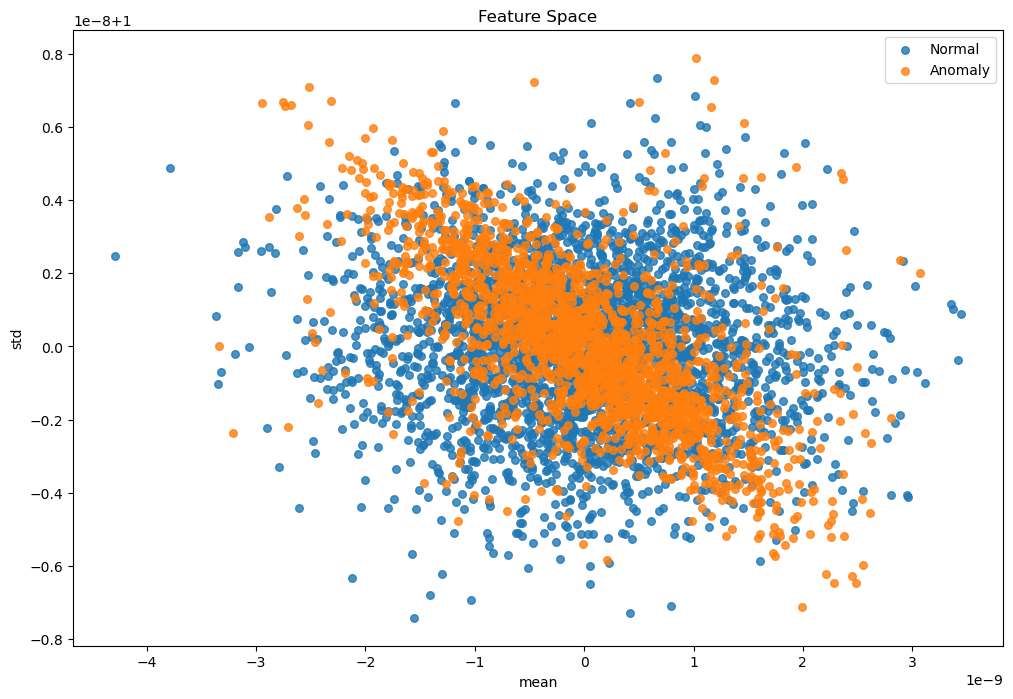

In [17]:
plot_feature_space(
    df=full_df,
    feature_columns=['mean', 'std'],
    label_column='label',
    alpha=0.8,
)

The combination of amplitude and median shows a much clearer separation. Normal series tend to cluster at higher amplitudes, while anomalies concentrate at lower amplitudes with higher median values. This suggests that amplitude is a key discriminative feature for the Mahalanobis method.

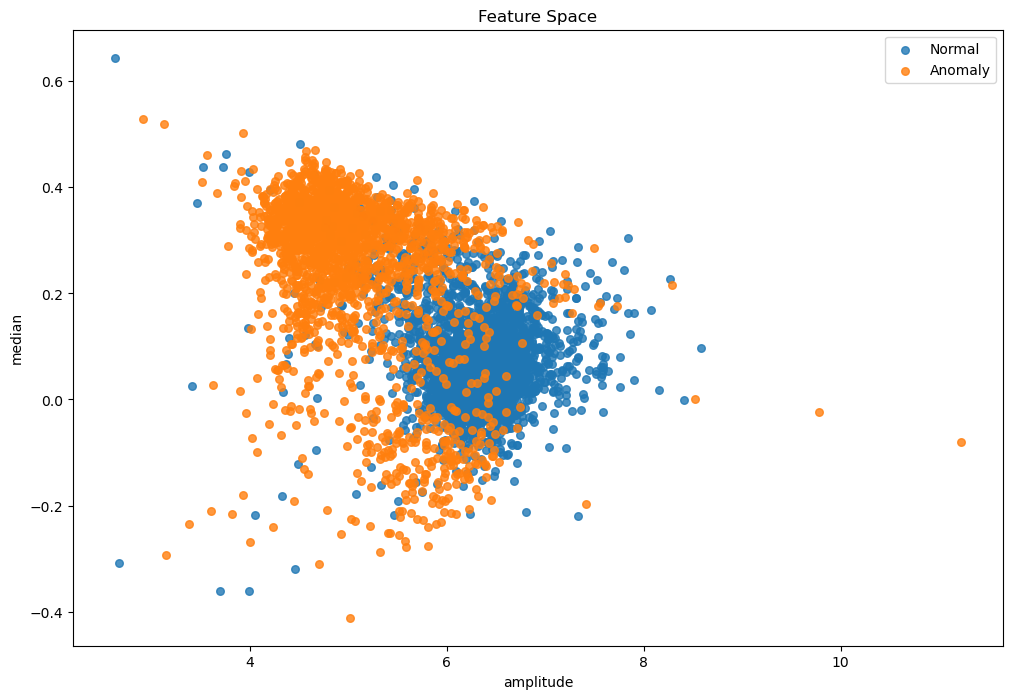

In [18]:
plot_feature_space(
    df=full_df,
    feature_columns=['amplitude', 'median'],
    label_column='label',
    alpha=0.8,
)

## Conclusion

The Mahalanobis baseline performed remarkably well (macro avg F1-score: 0.91) because the anomalies in this dataset exhibit distinct statistical characteristics, particularly in amplitude and median, that are clearly separable from normal series. This indicates that the data can be largely classified using summary statistics alone, without considering the sequential and temporal patterns within the time series. This raises an important question for the Conv1D Autoencoder: can leveraging temporal structure provide a meaningful improvement over a purely statistical approach?